<a href="https://colab.research.google.com/github/Mithiles-19/OIBSIP/blob/main/Task7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [9]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/creditcard.csv")

# Inspect dataset
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Data Integrity & Class Imbalance Check

In [11]:
# Class distribution
class_counts = df["Class"].value_counts()
class_counts

# Percentage of fraud cases
fraud_ratio = class_counts[1] / class_counts.sum() * 100
print(f"Fraud Percentage: {fraud_ratio:.4f}%")


Fraud Percentage: 0.1727%


Feature Engineering
3.1 Feature Scaling (Amount & Time)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])

# Drop original columns
df = df.drop(["Amount", "Time"], axis=1)


3.2 Split Features & Target

In [13]:
X = df.drop("Class", axis=1)
y = df["Class"]


In [5]:
X = data.drop('Class', axis=1)
y = data['Class']

In [6]:
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

In [14]:
y.isna().sum()

# Combine X and y temporarily
data = pd.concat([X, y], axis=1)

# Drop rows where Class is NaN
data = data.dropna(subset=["Class"])

# Split again
X = data.drop("Class", axis=1)
y = data["Class"]


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [16]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [17]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721669425367221


In [18]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [19]:
print("Decision Tree Report")
print(classification_report(y_test, dt_pred))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.71      0.71        98

    accuracy                           1.00     56962
   macro avg       0.85      0.86      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.8568878627703193


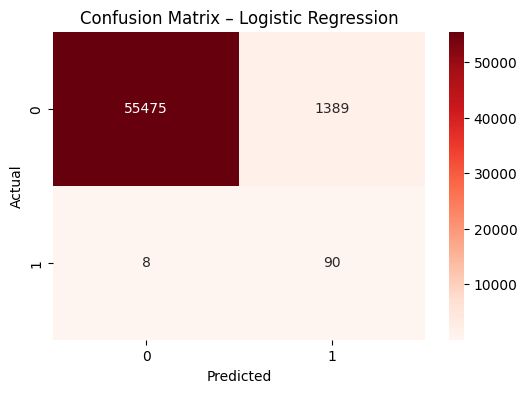

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
